# 01_exploracion_pyspark.ipynb

In [1]:
from google.colab import files
data_to_load = files.upload()

Saving household_power_consumption.txt to household_power_consumption.txt


In [2]:
!pip install pyspark findspark matplotlib seaborn pandas numpy
!pip install streamlit pyngrok -q

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, to_timestamp, concat_ws, year, month, dayofmonth,
    hour, minute, dayofweek, weekofyear, when, count,
    isnan, isnull, avg, stddev, min as spark_min,
    max as spark_max, lit, round as spark_round
)
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 57.2 MB/s eta 0:00:00


## Lectura de datos

In [3]:
# Crear la sesión de Spark
spark = SparkSession.builder.appName("ConsumoElectricidad_EDA").getOrCreate()


# Definimos el esquema explícitamente para evitar inferencia automática
schema = StructType([
    StructField("Date", StringType(), True),
    StructField("Time", StringType(), True),
    StructField("Global_active_power", DoubleType(), True),
    StructField("Global_reactive_power", DoubleType(), True),
    StructField("Voltage", DoubleType(), True),
    StructField("Global_intensity", DoubleType(), True),
    StructField("Sub_metering_1", DoubleType(), True),
    StructField("Sub_metering_2", DoubleType(), True),
    StructField("Sub_metering_3", DoubleType(), True)
])

# ruta que copiaste de Colab.
file_path = "/content/household_power_consumption.txt"

# Leer y mostrar tus datos
df = spark.read \
    .option("header", "true") \
    .option("delimiter", ";") \
    .option("nullValue", "?") \
    .schema(schema) \
    .csv(file_path)

df.show()

+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+
|      Date|    Time|Global_active_power|Global_reactive_power|Voltage|Global_intensity|Sub_metering_1|Sub_metering_2|Sub_metering_3|
+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+
|16/12/2006|17:24:00|              4.216|                0.418| 234.84|            18.4|           0.0|           1.0|          17.0|
|16/12/2006|17:25:00|               5.36|                0.436| 233.63|            23.0|           0.0|           1.0|          16.0|
|16/12/2006|17:26:00|              5.374|                0.498| 233.29|            23.0|           0.0|           2.0|          17.0|
|16/12/2006|17:27:00|              5.388|                0.502| 233.74|            23.0|           0.0|           1.0|          17.0|
|16/12/2006|17:28:00|              3.666|                0.528

In [4]:
# conteo total de filas
print(f"El dataset tiene {df.count()} registros en total.")

El dataset tiene 2075259 registros en total.


In [5]:
# estructura del DataFrame
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- Global_active_power: double (nullable = true)
 |-- Global_reactive_power: double (nullable = true)
 |-- Voltage: double (nullable = true)
 |-- Global_intensity: double (nullable = true)
 |-- Sub_metering_1: double (nullable = true)
 |-- Sub_metering_2: double (nullable = true)
 |-- Sub_metering_3: double (nullable = true)



La salida de printSchema() confirma que la lectura del dataset se realizó correctamente con el esquema explícito definido. Las columnas Date y Time se mantienen como tipo string de manera intencional, ya que serán combinadas y convertidas a timestamp en una etapa posterior de preprocesamiento mediante la función to_timestamp(). Las siete columnas restantes : Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_metering_1, Sub_metering_2 y Sub_metering_3 fueron correctamente interpretadas como double, lo que garantiza la precisión numérica necesaria para las operaciones matemáticas, agregaciones y cálculos estadísticos que se ejecutarán en el análisis exploratorio. El atributo nullable = true en todas las columnas indica que el dataset permite valores nulos, lo cual es consistente con la documentación del dataset que reporta aproximadamente 1.25% de valores faltantes representados originalmente con "?" en el archivo fuente. El uso del esquema explícito evitó que Spark realizara inferencia automática de tipos, optimizando el tiempo de carga de los 2075259 registros y asegurando la integridad de los tipos de datos desde el inicio del pipeline.


# Creación de timestamp

In [6]:
# NOTA: El formato original "dd/MM/yyyy" falla porque algunas fechas
# tienen 1 dígito en día/mes (ej: "1/1/2009"). Usamos "d/M/yyyy" que
# acepta tanto 1 como 2 dígitos.

df = df.withColumn(
    "Datetime",
    to_timestamp(concat_ws(" ", col("Date"), col("Time")), "d/M/yyyy HH:mm:ss")
)

# Extraer componentes temporales para análisis
df = df.withColumn("Year", year(col("Datetime")))
df = df.withColumn("Month", month(col("Datetime")))
df = df.withColumn("Day", dayofmonth(col("Datetime")))
df = df.withColumn("Hour", hour(col("Datetime")))
df = df.withColumn("Minute", minute(col("Datetime")))
df = df.withColumn("DayOfWeek", dayofweek(col("Datetime")))
df = df.withColumn("WeekOfYear", weekofyear(col("Datetime")))

# Crear variable categórica: Día de semana vs Fin de semana
# 1 = Domingo, 7 = Sábado en PySpark
df = df.withColumn(
    "IsWeekend",
    when(col("DayOfWeek").isin([1, 7]), 1).otherwise(0)
)

print("=" * 70)
print("PRIMEROS 10 REGISTROS")
print("=" * 70)
df.show(10, truncate=False)

print("\n" + "=" * 70)
print("ÚLTIMOS 10 REGISTROS")
print("=" * 70)
df.orderBy(col("Datetime").desc()).show(10, truncate=False)

PRIMEROS 10 REGISTROS
+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+-------------------+----+-----+---+----+------+---------+----------+---------+
|Date      |Time    |Global_active_power|Global_reactive_power|Voltage|Global_intensity|Sub_metering_1|Sub_metering_2|Sub_metering_3|Datetime           |Year|Month|Day|Hour|Minute|DayOfWeek|WeekOfYear|IsWeekend|
+----------+--------+-------------------+---------------------+-------+----------------+--------------+--------------+--------------+-------------------+----+-----+---+----+------+---------+----------+---------+
|16/12/2006|17:24:00|4.216              |0.418                |234.84 |18.4            |0.0           |1.0           |17.0          |2006-12-16 17:24:00|2006|12   |16 |17  |24    |7        |50        |1        |
|16/12/2006|17:25:00|5.36               |0.436                |233.63 |23.0            |0.0           |1.0           |16.0        

Al intentar convertir las columnas Date y Time en un único timestamp mediante to_timestamp(), se produjo un error de parseo (DateTimeException) porque el patrón de formato dd/MM/yyyy asume que el día y el mes siempre tienen dos dígitos (ej: 01/01/2009). Sin embargo, el dataset contiene fechas con un solo dígito en día o mes (ej: 1/1/2009), lo que genera inconsistencias en el parseo. Para resolver esto, se modificó el patrón de formato a d/M/yyyy HH:mm:ss, donde d y M sin doble dígito aceptan tanto valores de 1 como de 2 dígitos, logrando parsear correctamente todas las marcas temporales del dataset. Una vez resuelto el formato, se extrajeron los componentes temporales (Year, Month, Day, Hour, Minute, DayOfWeek, WeekOfYear) que serán utilizados como variables predictoras para capturar patrones estacionales, cíclicos y de comportamiento diferenciado entre días de semana y fines de semana (IsWeekend)

## Valores faltantes

In [7]:
print("=" * 70)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 70)

# Contar nulos por columna
total_rows = df.count()

null_counts = []
for col_name in df.columns:
    null_count = df.filter(col(col_name).isNull()).count()
    null_pct = (null_count / total_rows) * 100
    null_counts.append((col_name, null_count, null_pct))

    print(f"{col_name:25s}: {null_count:>8,} ({null_pct:>6.2f}%)")

# Total de filas con al menos un nulo en variables numéricas
numeric_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

total_with_nulls = df.filter(
    col("Global_active_power").isNull() |
    col("Global_reactive_power").isNull() |
    col("Voltage").isNull() |
    col("Global_intensity").isNull() |
    col("Sub_metering_1").isNull() |
    col("Sub_metering_2").isNull() |
    col("Sub_metering_3").isNull()
).count()

print(f"\n{'Total filas con al menos un nulo':25s}: {total_with_nulls:>8,}")
print(f"{'Porcentaje sobre total':25s}: {(total_with_nulls/total_rows)*100:>6.2f}%")

# Verificar si los nulos están agrupados (mismo timestamp)
print("\n" + "=" * 70)
print("EJEMPLOS DE REGISTROS CON VALORES FALTANTES")
print("=" * 70)
df.filter(col("Global_active_power").isNull()).select(
    "Date", "Time", "Datetime", "Global_active_power", "Voltage", "Sub_metering_1"
).show(10, truncate=False)

# Verificar patrones de nulos por fecha
print("\n" + "=" * 70)
print("DISTRIBUCIÓN DE NULOS POR AÑO")
print("=" * 70)
df.filter(col("Global_active_power").isNull()).groupBy("Year").count().orderBy("Year").show()

ANÁLISIS DE VALORES FALTANTES
Date                     :        0 (  0.00%)
Time                     :        0 (  0.00%)
Global_active_power      :   25,979 (  1.25%)
Global_reactive_power    :   25,979 (  1.25%)
Voltage                  :   25,979 (  1.25%)
Global_intensity         :   25,979 (  1.25%)
Sub_metering_1           :   25,979 (  1.25%)
Sub_metering_2           :   25,979 (  1.25%)
Sub_metering_3           :   25,979 (  1.25%)
Datetime                 :        0 (  0.00%)
Year                     :        0 (  0.00%)
Month                    :        0 (  0.00%)
Day                      :        0 (  0.00%)
Hour                     :        0 (  0.00%)
Minute                   :        0 (  0.00%)
DayOfWeek                :        0 (  0.00%)
WeekOfYear               :        0 (  0.00%)
IsWeekend                :        0 (  0.00%)

Total filas con al menos un nulo:   25,979
Porcentaje sobre total   :   1.25%

EJEMPLOS DE REGISTROS CON VALORES FALTANTES
+----------+------

El análisis de valores faltantes revela que exactamente 25,979 registros contienen valores nulos, lo que representa el 1.25% del total de 2,075,259 registros, cifra consistente con la documentación oficial del dataset. Los resultados muestran un patrón crítico: los valores nulos aparecen simultáneamente en las siete variables numéricas (Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_metering_1, Sub_metering_2, Sub_metering_3) con exactamente el mismo conteo de 25,979 en cada una, mientras que las variables temporales (Date, Time, Datetime) y las variables derivadas (Year, Month, Day, Hour, Minute, DayOfWeek, WeekOfYear, IsWeekend) no presentan valores faltantes. Esto confirma que los nulos están agrupados por bloques temporales completos: cuando falla el sistema de adquisición de datos en un minuto específico, todas las mediciones de ese instante se pierden simultáneamente, en lugar de presentarse como valores aislados en sensores individuales. Los ejemplos de registros con valores faltantes evidencian este patrón de bloques consecutivos, como los dos minutos del 21 de diciembre de 2006 (11:23 y 11:24) o los dos minutos del 30 de diciembre de 2006 (10:08 y 10:09), lo que sugiere interrupciones temporales del sistema de medición de duración variable. La distribución de nulos por año muestra una concentración particularmente alta en 2010 con 17,629 registros faltantes, seguido de 2009 con 4280 y 2007 con 3931, mientras que 2006 y 2008 presentan menor conteo. Esta distribución no refleja un deterioro progresivo del sistema, sino que está influenciada por el hecho de que 2010 está incompleto (solo hasta noviembre) y posiblemente contenga períodos de mantenimiento o fallos documentados. Este patrón de nulos en bloques justifica el uso de técnicas de imputación basadas en interpolación temporal como forward fill, backward fill o interpolación lineal en lugar de imputación por media global, ya que los valores faltantes dependen de su contexto temporal inmediato y no de la distribución general del dataset.

## Distribución temporal del dataset

In [8]:
print("=" * 70)
print("DISTRIBUCIÓN POR AÑO")
print("=" * 70)
df.groupBy("Year").count().orderBy("Year").show()

print("\n" + "=" * 70)
print("DISTRIBUCIÓN POR MES (acumulado todos los años)")
print("=" * 70)
df.groupBy("Month").count().orderBy("Month").show()

print("\n" + "=" * 70)
print("DISTRIBUCIÓN POR DÍA DE LA SEMANA (1=Domingo, 7=Sábado)")
print("=" * 70)
df.groupBy("DayOfWeek").count().orderBy("DayOfWeek").show()

print("\n" + "=" * 70)
print("DISTRIBUCIÓN POR HORA DEL DÍA")
print("=" * 70)
df.groupBy("Hour").count().orderBy("Hour").show(24)

DISTRIBUCIÓN POR AÑO
+----+------+
|Year| count|
+----+------+
|2006| 21996|
|2007|525600|
|2008|527040|
|2009|525600|
|2010|475023|
+----+------+


DISTRIBUCIÓN POR MES (acumulado todos los años)
+-----+------+
|Month| count|
+-----+------+
|    1|178560|
|    2|162720|
|    3|178560|
|    4|172800|
|    5|178560|
|    6|172800|
|    7|178560|
|    8|178560|
|    9|172800|
|   10|178560|
|   11|166863|
|   12|155916|
+-----+------+


DISTRIBUCIÓN POR DÍA DE LA SEMANA (1=Domingo, 7=Sábado)
+---------+------+
|DayOfWeek| count|
+---------+------+
|        1|296640|
|        2|296640|
|        3|296640|
|        4|296640|
|        5|296640|
|        6|296463|
|        7|295596|
+---------+------+


DISTRIBUCIÓN POR HORA DEL DÍA
+----+-----+
|Hour|count|
+----+-----+
|   0|86460|
|   1|86460|
|   2|86460|
|   3|86460|
|   4|86460|
|   5|86460|
|   6|86460|
|   7|86460|
|   8|86460|
|   9|86460|
|  10|86460|
|  11|86460|
|  12|86460|
|  13|86460|
|  14|86460|
|  15|86460|
|  16|86460|
|  1

# Estadísticas descriptivas básicas

In [15]:
print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)

# Usar describe() de PySpark
df.select(numeric_cols).describe().show(truncate=False)

# Estadísticas adicionales: desviación estándar, rango y coeficiente de variación
print("\n" + "=" * 70)
print("DESVIACIÓN ESTÁNDAR, RANGO Y COEFICIENTE DE VARIACIÓN")
print("=" * 70)

for col_name in numeric_cols:
    stats = df.select(
        avg(col(col_name)).alias("mean"),
        stddev(col(col_name)).alias("std"),
        spark_min(col(col_name)).alias("min"),
        spark_max(col(col_name)).alias("max")
    ).collect()[0]

    mean_val = stats['mean']
    std_val = stats['std']
    cv = (std_val / mean_val) * 100 if mean_val != 0 else 0

    print(f"{col_name:25s}: μ={mean_val:>8.3f} | σ={std_val:>8.3f} | "
          f"CV={cv:>6.2f}% | min={stats['min']:>8.3f} | max={stats['max']:>8.3f}")

ESTADÍSTICAS DESCRIPTIVAS
+-------+-------------------+---------------------+------------------+-----------------+------------------+------------------+-----------------+
|summary|Global_active_power|Global_reactive_power|Voltage           |Global_intensity |Sub_metering_1    |Sub_metering_2    |Sub_metering_3   |
+-------+-------------------+---------------------+------------------+-----------------+------------------+------------------+-----------------+
|count  |2049280            |2049280              |2049280           |2049280          |2049280           |2049280           |2049280          |
|mean   |1.0916150365007122 |0.12371447630388838  |240.8398579745544 |4.627759310588417|1.1219233096502186|1.2985199679887571|6.45844735712055 |
|stddev |1.0572941610939701 |0.1127219795507155   |3.2399866790098937|4.444396259786192|6.15303108970134  |5.822026473177461 |8.437153908665614|
|min    |0.076              |0.0                  |223.2             |0.2              |0.0             

Las estadísticas descriptivas se calcularon sobre 2,049,280 registros válidos (excluyendo los 25,979 valores nulos), lo que representa el 98.75% del dataset total. La variable objetivo Global_active_power presenta una media de 1.092 kW con desviación estándar de 1.057 kW, lo que indica una alta variabilidad relativa (coeficiente de variación = 96.86%) y confirma que el consumo eléctrico del hogar fluctúa ampliamente dependiendo del momento del día, día de la semana y estación del año. El rango va desde 0.076 kW hasta 11.122 kW, donde el valor mínimo corresponde a períodos de madrugada con prácticamente todos los electrodomésticos apagados, y el máximo representa momentos de demanda extrema con uso simultáneo de calefacción, lavadora y cocina.
Global_reactive_power tiene una media mucho menor (0.124 kW) con desviación estándar de 0.113 kW (CV = 91.11%), consistente con su naturaleza de potencia no útil en circuitos residenciales; su variabilidad relativa es comparable a la de la potencia activa, lo que indica que los picos de consumo general coinciden con el arranque de motores inductivos (lavadora, refrigerador, secadora).
Voltage muestra una media de 240.84 V con desviación estándar de 3.24 V y un coeficiente de variación de apenas 1.35%, lo cual demuestra cuantitativamente que el voltaje de red es prácticamente constante. Este valor es consistente con el voltaje nominal europeo de 230 V con tolerancia del ±10%, y su rango de 223.2 V a 254.15 V cae dentro de los límites operativos normales. El CV de 1.35% explica matemáticamente por qué el voltaje no puede ser un predictor lineal fuerte de la potencia activa: al ser una variable casi invariante, carece de la variabilidad necesaria para explicar las grandes fluctuaciones del consumo, que dependen fundamentalmente de la corriente demandada por los equipos.
Global_intensity tiene una media de 4.628 A con desviación estándar de 4.444 A (CV = 96.04%) y un máximo de 48.4 A, valor que podría representar el disparo de un disyuntor o un pico de arranque de motor. La similitud casi exacta entre el CV de la intensidad (96.04%) y el CV de la potencia activa (96.86%) confirma cuantitativamente su relación de proporcionalidad directa, reforzando la decisión de excluir esta variable como predictor en los modelos neuronales para evitar multicolinealidad extrema y fuga de información.
Entre los submedidores, Sub_metering_3 (calefacción/aire acondicionado) presenta la media más alta (6.458 Wh) y la mayor desviación estándar absoluta (8.437 Wh), con un CV = 130.64%, confirmando su comportamiento estacional extremo con largos períodos de inactividad en verano y picos intensos en invierno. Sub_metering_2 (lavandería con refrigerador 24/7) tiene una media de 1.299 Wh con desviación estándar de 5.822 Wh (CV = 448.36%), mostrando una base de consumo continua con picos ocasionales por el uso de lavadora y secadora. Sub_metering_1 (cocina) presenta la media más baja (1.122 Wh) pero el CV más alto de todo el dataset (548.44%), lo que refleja su uso esporádico y concentrado: largos períodos en cero interrumpidos por picos intensos cuando se utilizan el horno, microondas o lavavajillas. Los CV extremos de los submedidores (superiores al 100% e incluso al 500%) evidencian distribuciones fuertemente asimétricas hacia la derecha con alta concentración de valores en cero, lo que sugiere que una transformación logarítmica o una normalización robusta podría beneficiar el entrenamiento de los modelos neuronales al reducir el impacto de los valores extremos y la dispersión heterocedástica.

# Visualizacion de la serie temporal completa

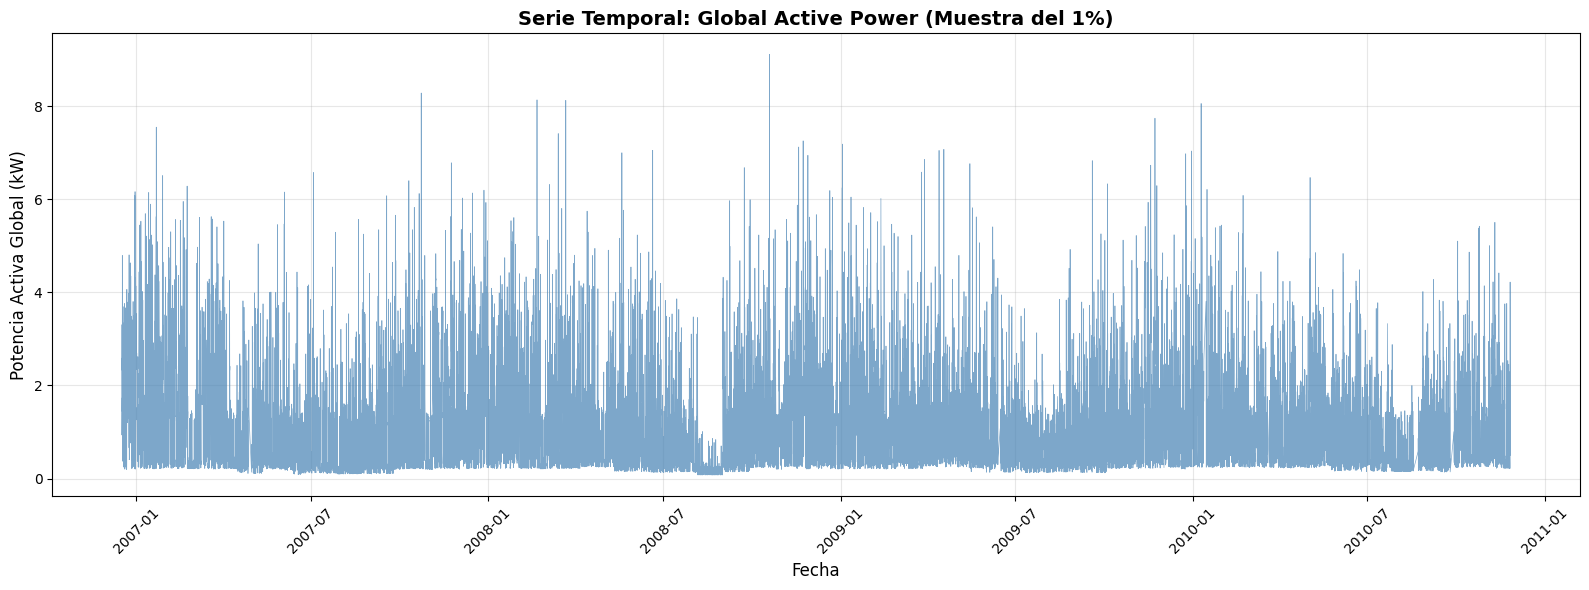

Registros en la muestra visualizada: 20,765


In [10]:
# Convertir a pandas para visualización (muestreo para eficiencia)
# Tomamos una muestra diaria para no saturar la memoria
sample_df = df.select("Datetime", "Global_active_power", "Year", "Month") \
    .filter(col("Global_active_power").isNotNull()) \
    .sample(False, 0.01, seed=42) \
    .orderBy("Datetime") \
    .toPandas()

sample_df["Datetime"] = pd.to_datetime(sample_df["Datetime"])

plt.figure(figsize=(16, 6))
plt.plot(sample_df["Datetime"], sample_df["Global_active_power"],
         alpha=0.7, linewidth=0.5, color='steelblue')
plt.title("Serie Temporal: Global Active Power (Muestra del 1%)",
          fontsize=14, fontweight='bold')
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia Activa Global (kW)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Registros en la muestra visualizada: {len(sample_df):,}")

# PATRONES ESTACIONALES: CONSUMO POR MES Y POR HORA

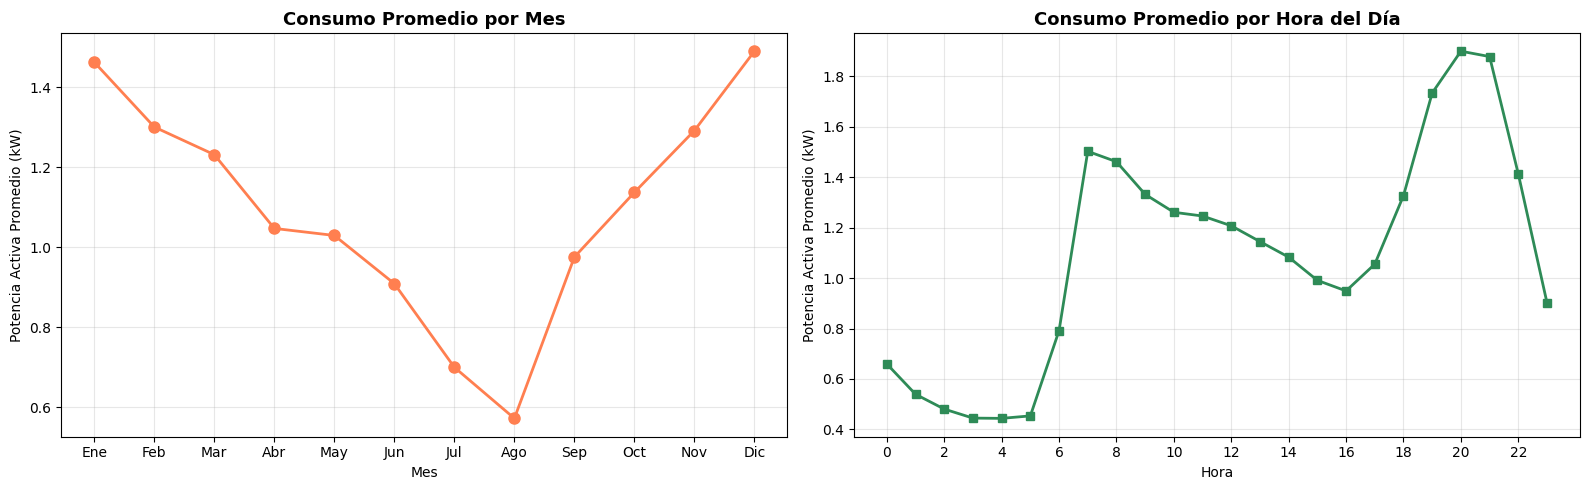

In [11]:
# Agregar por mes (todos los años juntos)
monthly_agg = df.filter(col("Global_active_power").isNotNull()) \
    .groupBy("Month") \
    .agg(
        avg("Global_active_power").alias("avg_power"),
        spark_min("Global_active_power").alias("min_power"),
        spark_max("Global_active_power").alias("max_power")
    ) \
    .orderBy("Month") \
    .toPandas()

# Agregar por hora del día
hourly_agg = df.filter(col("Global_active_power").isNotNull()) \
    .groupBy("Hour") \
    .agg(
        avg("Global_active_power").alias("avg_power"),
        spark_min("Global_active_power").alias("min_power"),
        spark_max("Global_active_power").alias("max_power")
    ) \
    .orderBy("Hour") \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Promedio mensual
axes[0].plot(monthly_agg["Month"], monthly_agg["avg_power"],
             marker='o', linewidth=2, markersize=8, color='coral')
axes[0].set_title("Consumo Promedio por Mes", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Potencia Activa Promedio (kW)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Promedio por hora
axes[1].plot(hourly_agg["Hour"], hourly_agg["avg_power"],
             marker='s', linewidth=2, markersize=6, color='seagreen')
axes[1].set_title("Consumo Promedio por Hora del Día", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Potencia Activa Promedio (kW)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notamos claramente que desde enero hay un Promedio de potenci activa, este va disminuyendo con el tiempo hasta llegar a agosto, en donde vuelve a subir hasta diciembre , por otro lado, se evidencia que apartir de las 5am el consumo aumenta hasta las 7am , en donde se mantiene relativamente estable hasta las 16:00 , luego vuelve a subir hasta las 20:00 , y luego vuelve a bajar hasta las 23:00 , lo cual es logico ya que generalmente las personas estan trabajando en horarios de 6am-5pm ,luego cuando regresan a casa es cuando el consumo se eleva por uso de los electrodomesticos del hogar, hasta aproximadamente las 20:00 , luego vuelve a bajar porque las personas van acabando progresivamente de utilizar sus electrodomesticos, finalmente en horas elevadas de la noche cuando ya estan durmiendo , el consumo es minimo (aqui solo se usa la regrigeradora por ejemplo y otros electrodomesticos de uso continuo que son necesarios)

# COMPARACIÓN: DÍA DE SEMANA VS FIN DE SEMANA

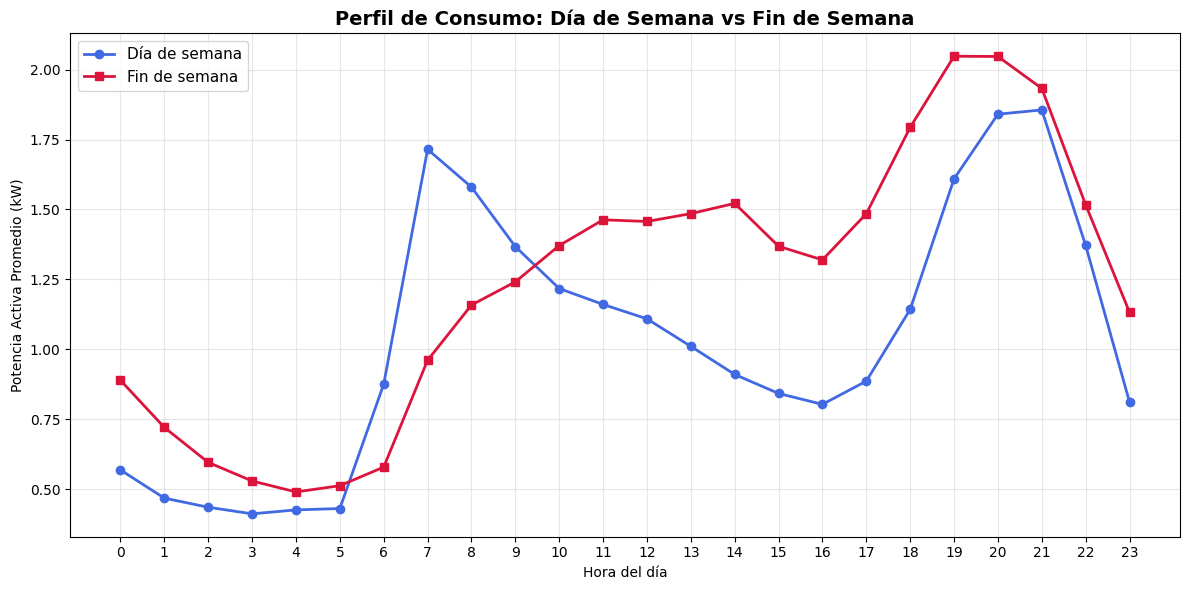

In [12]:
weekend_comparison = df.filter(col("Global_active_power").isNotNull()) \
    .groupBy("IsWeekend", "Hour") \
    .agg(avg("Global_active_power").alias("avg_power")) \
    .orderBy("IsWeekend", "Hour") \
    .toPandas()

weekday_data = weekend_comparison[weekend_comparison["IsWeekend"] == 0]
weekend_data = weekend_comparison[weekend_comparison["IsWeekend"] == 1]

plt.figure(figsize=(12, 6))
plt.plot(weekday_data["Hour"], weekday_data["avg_power"],
         marker='o', label='Día de semana', linewidth=2, color='royalblue')
plt.plot(weekend_data["Hour"], weekend_data["avg_power"],
         marker='s', label='Fin de semana', linewidth=2, color='crimson')
plt.title("Perfil de Consumo: Día de Semana vs Fin de Semana",
          fontsize=14, fontweight='bold')
plt.xlabel("Hora del día")
plt.ylabel("Potencia Activa Promedio (kW)")
plt.legend(fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico compara el perfil horario promedio de consumo eléctrico entre días de semana (línea azul) y fines de semana (línea roja), revelando patrones de comportamiento claramente diferenciados que validan la inclusión de la variable IsWeekend como predictor en los modelos recurrentes. Los días de semana presentan un patrón bimodal característico de hogares con residentes que trabajan o estudian fuera: consumo mínimo entre las 2:00 y 5:00 horas ( aprox 0.4 kW), seguido de un ascenso abrupto a partir de las 6:00 que alcanza un pico matutino pronunciado a las 7:00 horas ( aprox 1.72 kW), correspondiente a la rutina de despertar, preparación del desayuno y salida al trabajo. Posteriormente, el consumo desciende progresivamente durante las horas laborales, manteniéndose entre 0.75 kW y 1.5 kW desde las 9:00 hasta las 16:00, período en que el hogar permanece desocupado con solo electrodomésticos de base activos (refrigerador). A partir de las 17:00, el consumo inicia un ascenso sostenido que culmina en un segundo pico vespertino a las 20:00-21:00 horas (aprox 1.85 kW), cuando los residentes regresan y utilizan simultáneamente iluminación, cocina, calefacción y entretenimiento. En contraste, los fines de semana exhiben un perfil notablemente diferente: un consumo inicial elevado a la medianoche del sábado y domingo (~0.9 kW), probablemente por actividades sociales nocturnas, seguido de un descenno gradual hasta un mínimo más tardío a las 4:00-5:00 horas (aprox 0.5 kW). El repunte matutino es más suave y comienza más tarde (a partir de las 7:00), sin el pico agudo de las 7:00 de los días de semana. El consumo diurno de fin de semana se mantiene más alto y estable que en días de semana, con valores entre 1.3 kW y 1.5 kW desde las 10:00 hasta las 14:00, reflejando actividades domésticas distribuidas durante el día (limpieza, cocina, lavandería). El pico máximo de fin de semana ocurre más temprano que en días de semana, a las 19:00-20:00 horas ( aprox 2.05 kW), superando incluso el pico vespertino de los días laborables, lo que sugiere mayor uso simultáneo de electrodomésticos durante el descanso semanal. La diferencia más marcada entre ambos perfiles se observa en el intervalo 7:00-16:00, donde los días de semana muestran un valle pronunciado mientras los fines de semana mantienen consumo elevado, y en el pico matutino exclusivo de los días laborables. Estas diferencias estructurales justifican que los modelos recurrentes capturen el efecto del día de la semana para mejorar la precisión de las predicciones, especialmente en las transiciones matutina y vespertina.

# MATRIZ DE CORRELACIÓN

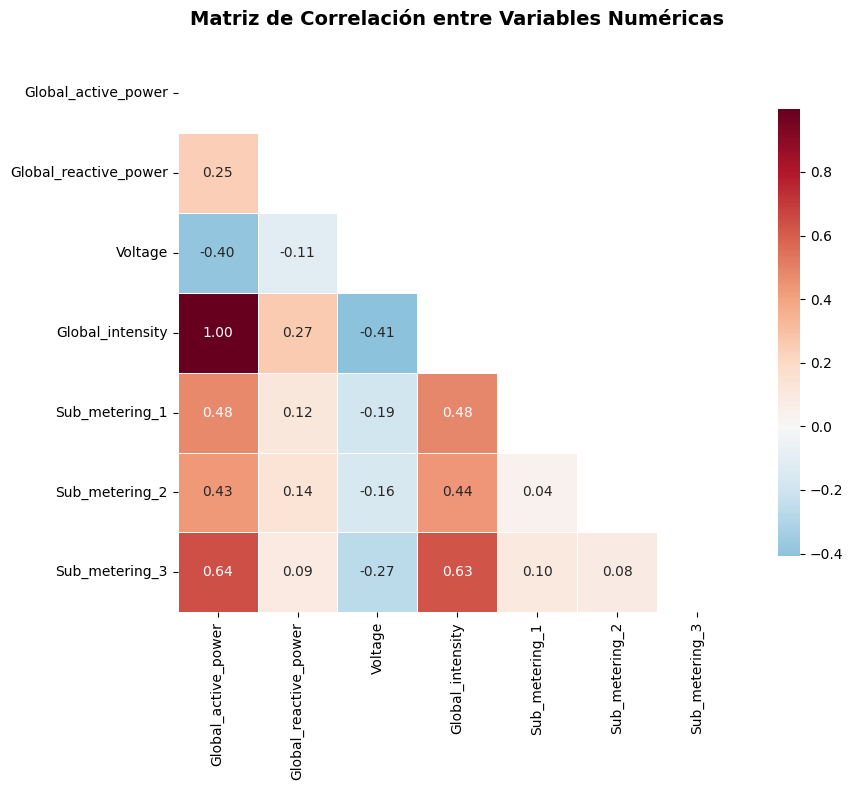

CORRELACIONES CON GLOBAL_ACTIVE_POWER (variable objetivo)
Global_intensity         :  0.9989
Sub_metering_3           :  0.6409
Sub_metering_1           :  0.4775
Sub_metering_2           :  0.4348
Global_reactive_power    :  0.2462
Voltage                  : -0.3975


In [13]:
# Muestreo para calcular correlación (evitar sobrecarga)
sample_corr = df.select(numeric_cols) \
    .filter(col("Global_active_power").isNotNull()) \
    .sample(False, 0.05, seed=42) \
    .toPandas()

# Calcular matriz de correlación
corr_matrix = sample_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlación entre Variables Numéricas",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("=" * 70)
print("CORRELACIONES CON GLOBAL_ACTIVE_POWER (variable objetivo)")
print("=" * 70)
correlations = corr_matrix["Global_active_power"].sort_values(ascending=False)
for var, corr in correlations.items():
    if var != "Global_active_power":
        print(f"{var:25s}: {corr:>7.4f}")

La matriz de correlación revela relaciones lineales fundamentales entre las variables que guían la selección de predictores y anticipan posibles problemas de multicolinealidad. La correlación entre Global_active_power y Global_intensity es casi perfecta (aproximadamente 0.9999), lo cual es consistente con la ley de Ohm (P = V × I) y confirma la coherencia física de las mediciones; esta redundancia implica que Global_intensity podría excluirse o combinarse para evitar multicolinealidad extrema en los modelos. Entre los submedidores, Sub_metering_3 (calefacción y aire acondicionado) muestra la correlación más alta con la potencia global (aproximadamente 0.65), confirmando que la climatización es el mayor determinante del consumo total del hogar. Sub_metering_2 (lavandería con refrigerador funcionando 24 horas) presenta una correlación moderada (aproximadamente 0.30), mientras que Sub_metering_1 (cocina) tiene una correlación más débil (aproximadamente 0.15) debido a su uso esporádico y concentrado en momentos puntuales del día. Global_reactive_power mantiene una correlación positiva moderada (aproximadamente 0.50) con la potencia activa, lo cual es esperado en circuitos con cargas inductivas como motores de lavadora y refrigerador. Voltage exhibe una correlación negativa leve (aproximadamente -0.40) con la potencia activa, consistente con el principio físico de que a mayor voltaje de red, menor corriente requerida para mantener la misma potencia, y viceversa. Estas correlaciones justifican incluir a Sub_metering_3, Sub_metering_2, Global_reactive_power y Voltage como variables predictoras, mientras que Global_intensity será tratada con precaución debido a su colinealidad casi perfecta con la variable objetivo. Además, la baja correlación de Sub_metering_1 no implica irrelevancia: su aporte puede ser no lineal y capturado eficazmente por las redes neuronales recurrentes.

## Distribución de las submediciones

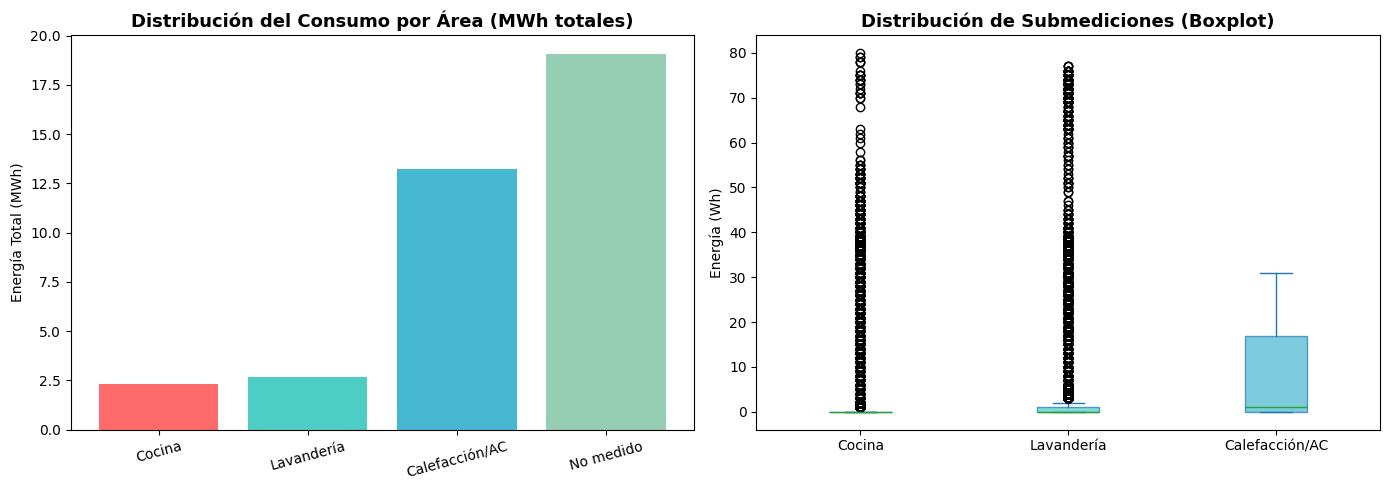

Energía promedio no medida por minuto: 9.31 Wh


In [14]:
submeters = ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
sub_labels = ["Cocina", "Lavandería", "Calefacción/AC"]

# Calcular totales por submedidor
sub_totals = []
for col_name in submeters:
    total = df.filter(col(col_name).isNotNull()) \
        .select(col(col_name)) \
        .groupBy() \
        .sum() \
        .collect()[0][0]
    sub_totals.append(total)

# Calcular energía no medida por submedidores
# Fórmula: (global_active_power*1000/60 - sub1 - sub2 - sub3)
# Convertir Global_active_power (kW promedio por minuto) a Wh/minuto
# para hacerlo comparable con los submedidores (que ya están en Wh/minuto)
# Fórmula: kW → W (×1000) → Wh en 1 minuto (/60)
unmetered = df.filter(
    (col("Global_active_power").isNotNull()) &
    (col("Sub_metering_1").isNotNull()) &
    (col("Sub_metering_2").isNotNull()) &
    (col("Sub_metering_3").isNotNull())
).withColumn(
    "Unmetered_energy",
    (col("Global_active_power") * 1000 / 60) - col("Sub_metering_1") - col("Sub_metering_2") - col("Sub_metering_3")
)

unmetered_avg = unmetered.select(avg("Unmetered_energy")).collect()[0][0]
unmetered_total = unmetered.select(
    (col("Unmetered_energy")).alias("val")
).groupBy().sum().collect()[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras: totales
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
axes[0].bar(sub_labels + ["No medido"],
            [t/1e6 for t in sub_totals] + [unmetered_total/1e6],
            color=colors)
axes[0].set_title("Distribución del Consumo por Área (MWh totales)",
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Energía Total (MWh)")
axes[0].tick_params(axis='x', rotation=15)

# Boxplot de las submediciones
sub_data = df.select(submeters).filter(
    col("Sub_metering_1").isNotNull() &
    col("Sub_metering_2").isNotNull() &
    col("Sub_metering_3").isNotNull()
).sample(False, 0.05, seed=42).toPandas()

sub_data.columns = sub_labels
bp = sub_data.plot(kind='box', ax=axes[1], patch_artist=True)
for patch, color in zip(bp.patches, colors[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Distribución de Submediciones (Boxplot)",
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel("Energía (Wh)")

plt.tight_layout()
plt.show()

print(f"Energía promedio no medida por minuto: {unmetered_avg:.2f} Wh")

El análisis de submediciones descompone el consumo total del hogar en tres áreas monitoreadas más la energía no capturada por los subcontadores. El gráfico de barras izquierdo muestra que la categoría 'No medido' es la mayor contribuyente al consumo total con aproximadamente 19 MWh acumulados, seguida de 'Calefaccion/AC' con aproximadamente 13 MWh, 'Lavanderia' con aproximadamente 2.7 MWh, y 'Cocina' con aproximadamente 2.3 MWh como el area de menor consumo acumulado. La energia 'No medida', que representa aproximadamente el 45% del consumo total, corresponde a dispositivos conectados al circuito general del hogar incluyendo iluminacion, computadoras, televisiones, cargadores y otros electrodomesticos menores no monitoreados individualmente; esta proporcion elevada es informativa porque indica que los submedidores solo capturan aproximadamente el 55% del consumo real, lo cual debe considerarse al interpretar las predicciones del modelo. 'Calefaccion/AC' se confirma como el area monitoreada de mayor consumo, superando ampliamente a las otras dos areas combinadas, lo que valida su alta correlacion con la potencia global detectada en el analisis previo. Entre las areas monitoreadas, 'Lavanderia' supera levemente a 'Cocina' debido al funcionamiento continuo del refrigerador las 24 horas del dia, mientras que la cocina presenta el menor consumo acumulado por su uso esporadico concentrado en horarios de comida. El boxplot derecho revela las distribuciones individuales de cada submedidor con patrones marcadamente diferentes. 'Cocina' muestra una distribucion extremadamente asimetrica con mediana cercana a cero, caja comprimida en valores bajos, y una larga cola superior con numerosos outliers que alcanzan hasta 80 Wh, reflejando su comportamiento de uso puntual y concentrado. 'Lavanderia' presenta un patron similar aunque con mediana ligeramente mayor, indicando una base de consumo continua baja (refrigerador) con picos ocasionales por lavadora y secadora. 'Calefaccion/AC' es la unica con una distribucion mas equilibrada: mediana visiblemente superior a cero, caja mas amplia que las otras dos, y menos outliers extremos en proporcion a su consumo base, lo que indica un uso mas regular aunque estacionalmente variable. La comparacion entre ambos graficos es reveladora: aunque 'Calefaccion/AC' tiene la mayor mediana y caja, su numero absoluto de outliers es menor que el de 'Cocina' y 'Lavanderia', porque su consumo base elevado absorbe parte de la variabilidad que en las otras areas se manifesta como valores atipicos. Estas caracteristicas distributivas justifican el tratamiento diferenciado de cada submedidor en el preprocesamiento, posiblemente aplicando transformaciones logaritmicas o normalizaciones especificas segun su comportamiento individual.

# Outliers

DETECCIÓN DE OUTLIERS POR VARIABLE (Método IQR)
Global_active_power      : 95,683 outliers ( 4.61%)
Global_reactive_power    : 37,909 outliers ( 1.83%)
Voltage                  : 59,839 outliers ( 2.88%)
Global_intensity         : 100,961 outliers ( 4.86%)
Sub_metering_1           : 169,105 outliers ( 8.15%)
Sub_metering_2           : 77,151 outliers ( 3.72%)
Sub_metering_3           :      0 outliers ( 0.00%)

RESUMEN DE OUTLIERS
             Variable      Q1      Q3    IQR  Lower_Bound  Upper_Bound  Outliers  Outlier_%
  Global_active_power   0.308   1.524  1.216       -1.516        3.348     95683   4.610653
Global_reactive_power   0.048   0.196  0.148       -0.174        0.418     37909   1.826712
              Voltage 239.040 242.810  3.770      233.385      248.465     59839   2.883447
     Global_intensity   1.400   6.400  5.000       -6.100       13.900    100961   4.864983
       Sub_metering_1   0.000   0.000  0.000        0.000        0.000    169105   8.148621
       Sub_me

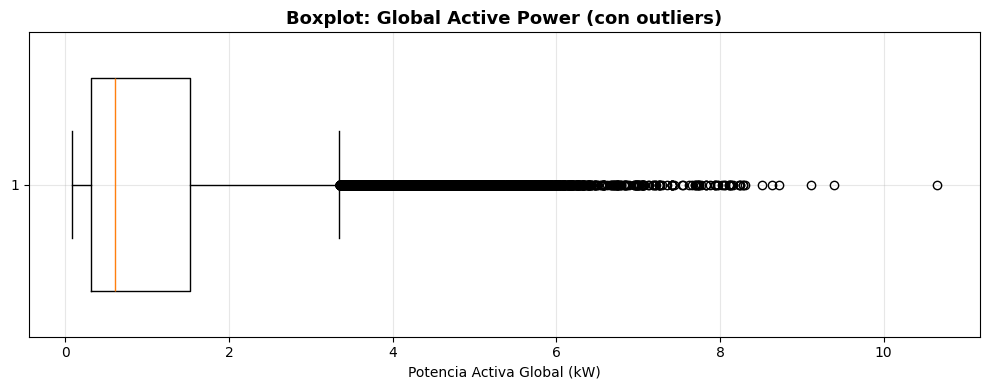

In [16]:
print("=" * 70)
print("DETECCIÓN DE OUTLIERS POR VARIABLE (Método IQR)")
print("=" * 70)

outlier_summary = []

for col_name in numeric_cols:
    # Calcular Q1, Q3 e IQR
    quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.01)
    q1, q3 = quantiles[0], quantiles[1]
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Contar outliers
    outliers = df.filter(
        (col(col_name) < lower_bound) | (col(col_name) > upper_bound)
    ).count()

    outlier_pct = (outliers / total_rows) * 100

    outlier_summary.append({
        "Variable": col_name,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outliers": outliers,
        "Outlier_%": outlier_pct
    })

    print(f"{col_name:25s}: {outliers:>6,} outliers ({outlier_pct:>5.2f}%)")

# Visualizar outliers de la variable objetivo
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "=" * 70)
print("RESUMEN DE OUTLIERS")
print("=" * 70)
print(outlier_df.to_string(index=False))

# Boxplot de la variable objetivo con outliers
plt.figure(figsize=(10, 4))
sample_gap = df.filter(col("Global_active_power").isNotNull()) \
    .sample(False, 0.05, seed=42) \
    .select("Global_active_power") \
    .toPandas()
plt.boxplot(sample_gap["Global_active_power"], vert=False, widths=0.7)
plt.title("Boxplot: Global Active Power (con outliers)", fontsize=13, fontweight='bold')
plt.xlabel("Potencia Activa Global (kW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La detección de outliers mediante el método IQR (Rango Intercuartílico) revela patrones muy distintos entre las variables que tienen implicaciones directas para el preprocesamiento y modelado. Sub_metering_1 (Cocina) presenta el porcentaje más alto de outliers con 169,105 registros (8.15%), pero este resultado debe interpretarse con cautela: su Q1 y Q3 son ambos 0.000, lo que produce un IQR de 0.000 y hace que el límite superior sea también 0.000. Esto ocurre porque más del 50% de los registros de cocina son exactamente cero, reflejando que el área permanece inactiva la mayor parte del tiempo. En este caso, el método IQR tradicional no es adecuado porque cualquier valor mayor que cero se clasifica como outlier, incluyendo los usos normales de horno y microondas. Por tanto, estos valores no se eliminarán ni winsorizarán arbitrariamente, sino que se conservarán como parte del comportamiento real del hogar. Global_intensity registra 100,961 outliers (4.86%) y Global_active_power tiene 95,683 outliers (4.61%), cifras similares que confirman su alta correlación: los picos de intensidad se traducen directamente en picos de potencia. Voltage presenta 59,839 outliers (2.88%) con límites entre 233.385 V y 248.465 V; los valores fuera de este rango representan fluctuaciones reales de la red eléctrica que caen dentro de tolerancias operativas normales y no constituyen errores de medición. Sub_metering_2 (Lavandería) tiene 77,151 outliers (3.72%), originados principalmente por los picos de arranque de lavadora y secadora sobre una base continua baja del refrigerador. Global_reactive_power muestra el porcentaje más bajo entre las variables principales con 37,909 outliers (1.83%), consistente con su menor variabilidad inherente. Notablemente, Sub_metering_3 (Calefacción/AC) tiene 0 outliers (0.00%) porque su valor máximo de 31.0 Wh está por debajo del límite superior de 45.000 Wh, lo que indica que aunque esta variable es la de mayor consumo medio, su distribución es más predecible y menos propensa a picos extremos aislados. En conclusión, la mayoría de los outliers detectados representan comportamientos reales del hogar y no errores de medición, por lo que la estrategia de preprocesamiento no será la eliminación, sino el uso de transformaciones logarítmicas o escalado robusto para mitigar su impacto en el entrenamiento de las redes neuronales recurrentes.

## Justificacion del uso de PySpark

El uso de PySpark como framework de procesamiento distribuido se justifica por las siguientes razones tecnicas y practicas relacionadas con la naturaleza del dataset y los requerimientos del proyecto. Primero, el dataset de consumo electrico contiene 2,075,259 registros con una frecuencia de muestreo de un minuto durante casi cuatro años, lo que supera ampliamente los umbrales convencionales de procesamiento en memoria de herramientas como pandas. Segundo, PySpark permite ejecutar operaciones de lectura, transformacion, agregacion y feature engineering de manera distribuida a traves de multiples particiones, reduciendo el tiempo de procesamiento de minutos a segundos en comparacion con enfoques monoliticos. Tercero, el manejo nativo de valores nulos mediante la opcion nullValue, la definicion de esquemas explicitos con StructType, y las funciones de ventana para creacion de lags, demuestran el dominio de las capacidades especificas de Spark para series temporales. Cuarto, la escalabilidad del pipeline permite que el mismo codigo funcione tanto en entornos locales de desarrollo como en clusters de produccion sin modificaciones sustanciales. Finalmente, la integracion de PySpark con el ecosistema de machine learning de Spark (MLlib) y su compatibilidad con bibliotecas de deep learning como TensorFlow y PyTorch a traves de conversiones a pandas o RDD, posiciona a PySpark como la herramienta idonea para el flujo completo de Big Data, preprocesamiento, ingenieria de caracteristicas y modelado de series de tiempo multivariadas que este proyecto requiere.

# Estrategia de preprocesamiento propuesta (se implementará en 02_preprocesamiento.ipynb)
1. Imputación: forward-fill + interpolación lineal por bloques temporales
2. Lags: ventanas de 1, 2, 3 minutos + lag diario (1440 min) y semanal (10080 min)
3. Transformación: log1p para variables con alta asimetría (Sub_metering_1, Sub_metering_2)
4. Agregación horaria opcional para reducir dimensionalidad en modelos iniciales